In [4]:
!pip install torch ultralytics roboflow supervision

In [5]:
from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("jacobs-workspace-5q9qs")
project = workspace.project("brain-tumor-segmentation-wltzi-4c9tf")
version = project.version(1)
dataset = version.download("coco-segmentation")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Brain-Tumor-Segmentation-1 in coco-segmentation:: 100%|██████████| 458/458 [00:00<00:00, 1680.05it/s]


In [6]:
!mkdir -p /content/train/images
!mkdir -p /content/train/masks
!mkdir -p /content/test/images
!mkdir -p /content/test/masks
!mkdir -p /content/valid/images
!mkdir -p /content/valid/masks

!cp /content/Brain-Tumor-Segmentation-1/train/* /content/train/images/
!cp /content/Brain-Tumor-Segmentation-1/test/* /content/test/images/
!cp /content/Brain-Tumor-Segmentation-1/valid/* /content/valid/images/

!rm -rf /content/Brain-Tumor-Segmentation-1

In [7]:
import json

with open("/content/train/images/_annotations.coco.json") as f:
    data_tr = json.load(f)
with open("/content/test/images/_annotations.coco.json") as f:
    data_te = json.load(f)
with open("/content/valid/images/_annotations.coco.json") as f:
    data_v = json.load(f)

In [8]:
import cv2
import numpy as np
import os
from collections import defaultdict

def build_and_save_masks(data,output_dir):
  images = data["images"]
  annotations = data["annotations"]

  annotations_map = defaultdict(list)
  for annotation in data["annotations"]:
    annotations_map[annotation["image_id"]].append(annotation)

  for img in images:
    img_id = img["id"]
    filename = img["file_name"]

    height, width = img["height"], img["width"]
    mask = np.zeros((height, width), dtype=np.uint8) # empty mask

    anns = annotations_map[img_id] # currently storing a list of the annotations applied to image img_id
    for annotation in anns: # currently storing an individual annotation in the annotations list recovered from annotations_map
      for segment in annotation["segmentation"]:
        poly = np.array(segment).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [poly], 1)

    mask_name = os.path.splitext(filename)[0] + ".png"
    mask_path = os.path.join(output_dir, mask_name)

    cv2.imwrite(mask_path, mask * 255)


In [9]:
build_and_save_masks(data_tr, "/content/train/masks/")
build_and_save_masks(data_te, "/content/test/masks/")
build_and_save_masks(data_v, "/content/valid/masks/")

In [10]:
!rm -rf /content/train/images/_annotations.coco.json
!rm -rf /content/test/images/_annotations.coco.json
!rm -rf /content//valid/images/_annotations.coco.json

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchsummary import summary

class UNetCNN(nn.Module):
  def __init__(self):
        super(UNetCNN, self).__init__()

        # block 1
        self.block1 = nn.Sequential(
          nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
          nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # block 2
        self.block2 = nn.Sequential(
          nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
          nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # block 3
        self.block3 = nn.Sequential(
          nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
          nn.ReLU()
        )
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # block 4
        self.block4 = nn.Sequential(
          nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
          nn.ReLU()
        )
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # block 5
        self.block5 = nn.Sequential(
          nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=2, stride=2)
        )

        # block 6 (up to level of block 4)
        self.block6 = nn.Sequential(
            nn.Conv2d(in_channels=1024, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)
        )

        # block 7 (up to level of block 3)
        self.block7 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        )

        # block 8 (up to level of block 2)
        self.block8 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        )

        # block 9 (up to level of block 1)
        self.block9 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=1, kernel_size=1, stride=1, padding=0)
        )


  def forward(self, x):
        x = self.block1(x)
        skip1 = x
        x = self.pool1(x)
        x = self.block2(x)
        skip2 = x
        x = self.pool2(x)
        x = self.block3(x)
        skip3 = x
        x = self.pool3(x)
        x = self.block4(x)
        skip4 = x
        x = self.pool4(x)
        x = self.block5(x)
        # skip4 = self.center_crop(skip4, x)
        x = torch.cat([x, skip4], dim=1)
        x = self.block6(x)
        # skip3 = self.center_crop(skip3, x)
        x = torch.cat([x, skip3], dim=1)
        x = self.block7(x)
        # skip2 = self.center_crop(skip2, x)
        x = torch.cat([x, skip2], dim=1)
        x = self.block8(x)
        # skip1 = self.center_crop(skip1, x)
        x = torch.cat([x, skip1], dim=1)
        x = self.block9(x)

        return x

  def center_crop(self, skip, x):
    _, _, H, W = x.shape
    _, _, Hs, Ws = skip.shape

    delta_h = (Hs - H) // 2
    delta_w = (Ws - W) // 2

    return skip[:, :, delta_h:delta_h+H, delta_w:delta_w+W]


In [12]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class SegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.image_files = os.listdir(image_dir)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        img_name = self.image_files[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", ".png"))

        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        image = transforms.ToTensor()(image)
        mask = transforms.ToTensor()(mask)

        mask = (mask > 0).float()

        return image, mask

In [22]:
from torch.utils.data import DataLoader

train_dataset = SegmentationDataset(
    "/content/train/images",
    "/content/train/masks"
)
test_dataset = SegmentationDataset(
    "/content/test/images",
    "/content/test/masks"
)
valid_dataset = SegmentationDataset(
    "/content/valid/images",
    "/content/valid/masks"
)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=True)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetCNN().to(device)
loss_function = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [15]:
def iou_score(preds, masks, eps=1e-6):

    preds = preds.bool()
    masks = masks.bool()

    intersection = (preds & masks).sum().float()
    union = (preds | masks).sum().float()

    return (intersection + eps) / (union + eps)

def dice_score(preds, masks, eps=1e-6):

    preds = preds.bool()
    masks = masks.bool()

    intersection = (preds & masks).sum().float()

    return (2 * intersection + eps) / (preds.sum() + masks.sum() + eps)

In [16]:
def train(model, dataloader, loss_function, optimizer, epochs):
    model.train()  # Set the model to training mode
    for epoch in range(epochs):
        total_loss = 0
        correct_pred = 0
        total_pred = 0
        total_dice = 0
        total_iou = 0

        for images, masks in train_loader:

            # Move tensors to GPU so compatible with model
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)

            # Clear gradients before performing backward pass
            optimizer.zero_grad()
            # Calculate loss based on model predictions
            loss = loss_function(outputs, masks)
            # Backpropagate and update model parameters
            loss.backward()
            optimizer.step()

            # multiply loss by total nos. of samples in batch

            total_loss += loss.item() * images.size(0)

            # convert logits → probabilities → binary mask
            preds = (torch.sigmoid(outputs) > 0.5).float()

            total_iou += iou_score(preds, masks).item()
            total_dice += dice_score(preds, masks).item()

        print(f"Epoch {epoch+1}; Loss: {total_loss/len(dataloader.dataset):.4f}; IoU:  {total_iou/len(dataloader):.4f}; Dice: {total_dice/len(dataloader):.4f}", flush=True)

In [23]:
train(model, train_loader, loss_function, optimizer, 20)

Epoch 1; Loss: 0.0846; IoU:  0.5907; Dice: 0.6779
Epoch 2; Loss: 0.0497; IoU:  0.7309; Dice: 0.8154
Epoch 3; Loss: 0.0434; IoU:  0.7546; Dice: 0.8294
Epoch 4; Loss: 0.0174; IoU:  0.8797; Dice: 0.9325
Epoch 5; Loss: 0.0137; IoU:  0.9032; Dice: 0.9474
Epoch 6; Loss: 0.0317; IoU:  0.8041; Dice: 0.8766
Epoch 7; Loss: 0.0144; IoU:  0.8920; Dice: 0.9389
Epoch 8; Loss: 0.0089; IoU:  0.9282; Dice: 0.9622
Epoch 9; Loss: 0.0078; IoU:  0.9346; Dice: 0.9658
Epoch 10; Loss: 0.0078; IoU:  0.9354; Dice: 0.9662
Epoch 11; Loss: 0.0114; IoU:  0.9150; Dice: 0.9535
Epoch 12; Loss: 0.0275; IoU:  0.8369; Dice: 0.8994
Epoch 13; Loss: 0.0111; IoU:  0.9155; Dice: 0.9538
Epoch 14; Loss: 0.0084; IoU:  0.9345; Dice: 0.9657
Epoch 15; Loss: 0.0070; IoU:  0.9392; Dice: 0.9680
Epoch 16; Loss: 0.0064; IoU:  0.9454; Dice: 0.9717
Epoch 17; Loss: 0.0099; IoU:  0.9259; Dice: 0.9602
Epoch 18; Loss: 0.0064; IoU:  0.9470; Dice: 0.9724
Epoch 19; Loss: 0.0061; IoU:  0.9504; Dice: 0.9742
Epoch 20; Loss: 0.0055; IoU:  0.9533; Di

In [1]:
import torch
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, device, num_samples=3):
    model.eval()

    with torch.no_grad():
        count = 0

        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if count >= num_samples:
                    return

                img = images[i].squeeze()
                mask = masks[i].squeeze()
                pred = preds[i].squeeze()

                plt.figure(figsize=(12,4))

                # Original Image
                plt.subplot(1,3,1)
                plt.title("Image")
                plt.imshow(img, cmap="gray")
                plt.axis("off")

                # Ground Truth
                plt.subplot(1,3,2)
                plt.title("Ground Truth")
                plt.imshow(mask, cmap="gray")
                plt.axis("off")

                # Prediction
                plt.subplot(1,3,3)
                plt.title("Prediction")
                plt.imshow(pred, cmap="gray")
                plt.axis("off")

                plt.show()

                count += 1

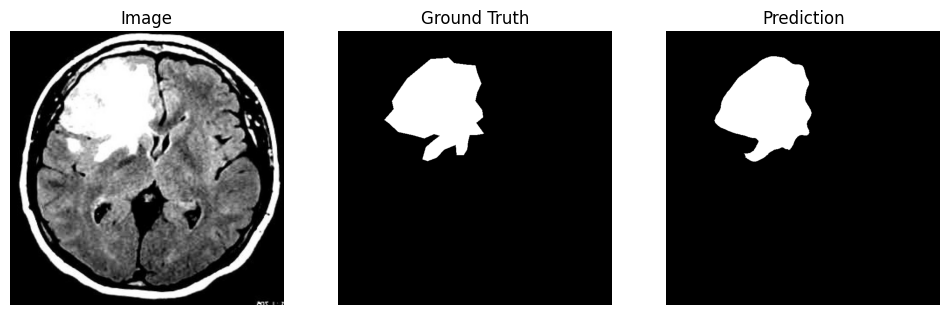

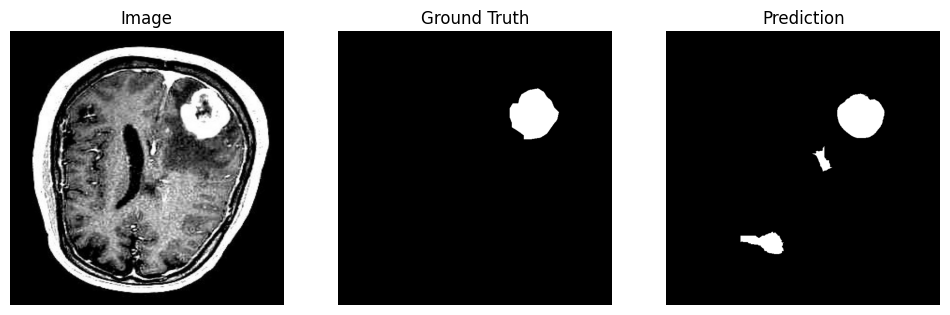

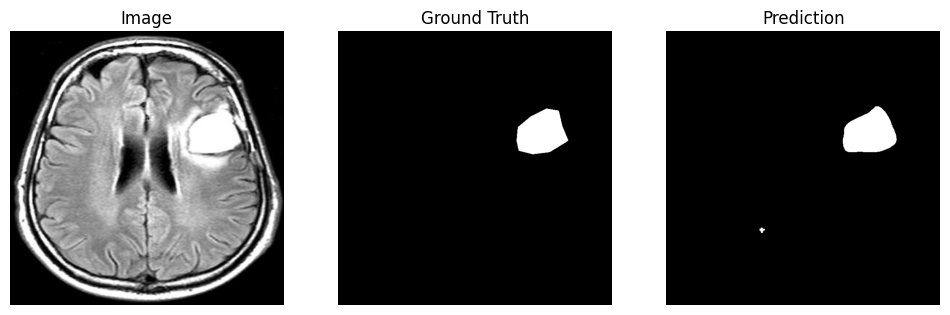

In [29]:
visualize_predictions(model, test_loader, device)

In [17]:
import torch

def save_checkpoint(model, optimizer, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, path)

def load_checkpoint(model, optimizer, path, device):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


In [25]:
from google.colab import drive
#drive.mount('/content/drive')

path = "/content/drive/MyDrive/unet_checkpoint.pth"
save_checkpoint(model, optimizer, path)
#load_checkpoint(model, optimizer, "/content/drive/MyDrive/unet_checkpoint.pth", device)